# Solar Rooftop Supply Chain Network Optimization using MILP and Power BI


## Business Case

India’s rooftop solar market is growing rapidly due to increasing energy demand, government incentives, and rising adoption of renewable energy solutions. However, solar equipment manufacturers and distributors face major operational challenges in determining the optimal locations of manufacturing and assembly facilities while minimizing logistics and operational costs.

This project focuses on designing an optimized supply chain network for rooftop solar panel distribution across major Indian cities. The goal is to determine the optimal allocation of manufacturing facilities to demand locations while balancing transportation costs, facility operating costs, service-level requirements, and capacity utilization constraints.

The project simulates a realistic business scenario where candidate manufacturing locations have already been shortlisted by procurement and land acquisition teams, and the optimization model determines how these facilities should serve regional demand in the most cost-efficient manner.

## Objective

The primary objective of this project is to minimize the total supply chain cost while satisfying regional rooftop solar demand across India.

The optimization model considers:

- Transportation cost
- Variable manufacturing cost
- Fixed facility operating cost
- Capacity constraints
- Minimum utilization constraints
- Service-level targets

The project also evaluates multiple service-level scenarios (40% to 100%) to analyze the trade-off between customer service and total network cost.

## Optimization Logic

The problem is formulated as a Mixed Integer Linear Programming (MILP) model.

### Decision Variables

- Shipment quantity from each manufacturing facility to each demand city
- Binary decision variable representing whether a facility is operational or not

### Objective Function

Minimize:

- Transportation Cost
- Production Cost
- Fixed Facility Cost

### Constraints

- Demand fulfillment constraints
- Facility capacity constraints
- Minimum facility utilization constraints
- Service-level constraints
- Oversupply prevention constraints

The optimization determines the most cost-efficient flow allocation across the network while ensuring operational feasibility.

## Business Assumptions

- Candidate manufacturing locations were pre-identified by procurement and land teams
- One 20 MT truck can transport approximately 1 MW of solar equipment
- Transportation cost is derived using diesel, toll, driver, and maintenance assumptions
- Demand values represent annual rooftop solar demand estimates
- Distances are approximated using geodesic calculations with circuity adjustment factors
- Service-level scenarios represent the percentage of total demand fulfilled

## 1. Data Preparation and Demand Generation

In [ ]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import for geocodes and distance
#!pip install geopy
from geopy.distance import geodesic


#!pip install pulp
import pulp

# import for plotting
import matplotlib.pyplot as plt


In [ ]:
demand = pd.read_csv(r"C:\Users\shahz\OneDrive\文件\Shahzeb\Projects\Solar Network Optimization\demand.csv")
sites = pd.read_csv(r"C:\Users\shahz\OneDrive\文件\Shahzeb\Projects\Solar Network Optimization\sites.csv")
circuity = pd.read_csv(r"C:\Users\shahz\OneDrive\文件\Shahzeb\Projects\Solar Network Optimization\circuity.csv")

In [ ]:
demand.head()

,S.No,City,Population,Demand MW/Yr,Region
0,1,Delhi,"3,20,00,000",145,North
1,2,Chandigarh,"12,00,000",18,North
2,3,Jaipur,"42,00,000",52,North
3,4,Lucknow,"39,00,000",38,North
4,5,Kanpur,"31,00,000",30,North


In [ ]:
demand.describe()

,S.No,Demand MW/Yr
count,25.000000,25.000000
mean,13.000000,54.560000
std,7.359801,42.449068
min,1.000000,14.000000
25%,7.000000,21.000000
50%,13.000000,34.000000
75%,19.000000,82.000000
max,25.000000,145.000000


In [ ]:
sites.head()

,Plant,City,Region,Capacity MW/Month,Fixed Cost/Year,Variable Cost/MW,Annual Capacity
0,A,Ahmedabad,West,30,"18,00,00,000","5,00,000",360
1,B,Jaipur,North,18,"11,00,00,000","4,50,000",216
2,C,Nagpur,Central,15,"9,00,00,000","4,80,000",180
3,D,Hyderabad,South,20,"15,00,00,000","4,30,000",240
4,E,Chennai,South,15,"14,00,00,000","4,60,000",180


In [ ]:
sites.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Plant              5 non-null      object
 1   City               5 non-null      object
 2   Region             5 non-null      object
 3   Capacity MW/Month  5 non-null      int64 
 4   Fixed Cost/Year    5 non-null      object
 5   Variable Cost/MW   5 non-null      object
 6   Annual Capacity    5 non-null      int64 
dtypes: int64(2), object(5)
memory usage: 412.0+ bytes


In [ ]:
sites['Fixed Cost/Year'] = sites['Fixed Cost/Year'].str.replace('$', '').str.replace(',', '').astype(float)
sites['Variable Cost/MWh'] = sites['Variable Cost/MW'].str.replace('$', '').str.replace(',', '').astype(float)

In [ ]:
cities = demand['City'].unique()
print(cities)


['Delhi' 'Chandigarh' 'Jaipur' 'Lucknow' 'Kanpur' 'Ahmedabad' 'Mumbai'
 'Pune' 'Surat' 'Indore' 'Nagpur' 'Bhopal' 'Bengaluru' 'Chennai'
 'Hyderabad' 'Coimbatore' 'Kochi' 'Kolkata' 'Bhubaneswar' 'Guwahati'
 'Patna' 'Ranchi' 'Visakhapatnam' 'Vijayawada' 'Raipur']


## 2. Latitude and Longitude Extraction using Geopy & Distance Matrix

In [ ]:

from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="solar_network")

cities_df = []
for city in cities:
    location = geolocator.geocode(city + ", India")
    city_lat = location.latitude
    city_lon = location.longitude
    cities_df.append({'City': city, 'Latitude': city_lat, 'Longitude': city_lon})

cities_df = pd.DataFrame(cities_df)
cities_df

,City,Latitude,Longitude
0,Delhi,28.613895,77.209006
1,Chandigarh,30.733442,76.779714
2,Jaipur,26.915458,75.818982
3,Lucknow,26.838100,80.934600
4,Kanpur,26.460914,80.321759
5,Ahmedabad,23.021537,72.580057
6,Mumbai,19.054999,72.869203
7,Pune,18.521374,73.854507
8,Surat,21.209489,72.831706
9,Indore,22.720362,75.868200


In [ ]:
demand = demand.merge(cities_df, on='City', how='left')
demand.head()

,S.No,City,Population,Demand MW/Yr,Region,Latitude,Longitude
0,1,Delhi,"3,20,00,000",145,North,28.613895,77.209006
1,2,Chandigarh,"12,00,000",18,North,30.733442,76.779714
2,3,Jaipur,"42,00,000",52,North,26.915458,75.818982
3,4,Lucknow,"39,00,000",38,North,26.838100,80.934600
4,5,Kanpur,"31,00,000",30,North,26.460914,80.321759


In [ ]:
sites=sites.merge(cities_df, on='City', how='left')
sites

,Plant,City,Region,Capacity MW/Month,Fixed Cost/Year,Variable Cost/MW,Annual Capacity,Variable Cost/MWh,Latitude,Longitude
0,A,Ahmedabad,West,30,180000000.0,"5,00,000",360,500000.0,23.021537,72.580057
1,B,Jaipur,North,18,110000000.0,"4,50,000",216,450000.0,26.915458,75.818982
2,C,Nagpur,Central,15,90000000.0,"4,80,000",180,480000.0,21.149813,79.082056
3,D,Hyderabad,South,20,150000000.0,"4,30,000",240,430000.0,17.360589,78.474061
4,E,Chennai,South,15,140000000.0,"4,60,000",180,460000.0,13.083694,80.270186


In [ ]:
circuity.head()

,Origin-Destination Pair,Estimated Circuity Factor,Geographical / Infrastructure Context
0,West-North,1.22,Fairly direct routing via NH48 and the Golden ...
1,West-West,1.25,Intra-region hauls often involve winding local...
2,West-Central,1.20,Direct trunk routes connecting the western por...
3,West-South,1.28,Higher circuity due to coastal curves and navi...
4,West-East,1.25,Long-haul routes across the peninsula; mostly ...


## 3. Lanes generation & Transportation Cost Modeling

In [ ]:
lanes = []

for i in range(len(demand)):
    for j in range(len(sites)):
        dest = demand.iloc[i]
        src = sites.iloc[j]
        lat1, lon1 = dest['Latitude'], dest['Longitude']
        lat2, lon2 = src['Latitude'], src['Longitude']

        if src['City'] == dest['City']:
            distance = 30  # Assume a default distance for intra-city connections
        else:
            distance = geodesic((lat1, lon1), (lat2, lon2)).km

        circuity_factor = float(circuity.loc[circuity['Origin-Destination Pair'] == str(src['Region']) + "-" + str(dest['Region']), 'Estimated Circuity Factor'].values[0])
        effective_distance = distance * circuity_factor

        lanes.append({'src': src['City'], 'dest': dest['City'],'Distance': effective_distance})

In [ ]:
lanes = pd.DataFrame(lanes)
lanes

,src,dest,Distance
0,Ahmedabad,Delhi,944.197364
1,Jaipur,Delhi,291.001659
2,Nagpur,Delhi,1017.778401
3,Hyderabad,Delhi,1528.612245
4,Chennai,Delhi,2133.189299
...,...,...,...
120,Ahmedabad,Raipur,1145.404556
121,Jaipur,Raipur,1035.452365
122,Nagpur,Raipur,318.154214
123,Hyderabad,Raipur,662.015391


In [ ]:
demand.head()

,S.No,City,Population,Demand MW/Yr,Region,Latitude,Longitude
0,1,Delhi,"3,20,00,000",145,North,28.613895,77.209006
1,2,Chandigarh,"12,00,000",18,North,30.733442,76.779714
2,3,Jaipur,"42,00,000",52,North,26.915458,75.818982
3,4,Lucknow,"39,00,000",38,North,26.838100,80.934600
4,5,Kanpur,"31,00,000",30,North,26.460914,80.321759


In [ ]:
lanes_df = pd.DataFrame(lanes)

In [ ]:
# one truck cost per lane
truck_cost_per_km = float(92/4) # Assuming 92 INR per 4 km mileage for a truck

# driver + toll = 18 INR/km
driver_toll_cost_per_km = float(18)

#maintaince and tire cost = 6 INR/km
maintenance_tire_cost_per_km = float(6)

#  miscellaneous cost = 3 INR/km
misc_cost_per_km = float(3)

lanes_df['transportation_cost_MW'] = lanes_df['Distance'].apply(lambda x: max(x * (truck_cost_per_km + driver_toll_cost_per_km +
                                                                                maintenance_tire_cost_per_km +
                                                                                misc_cost_per_km), 10000))

In [ ]:
lanes_df.rename(columns={'transportation_cost_MW': 'transport_cost'}, inplace=True)
lanes_df.head()

,src,dest,Distance,transport_cost
0,Ahmedabad,Delhi,944.197364,47209.868189
1,Jaipur,Delhi,291.001659,14550.082945
2,Nagpur,Delhi,1017.778401,50888.920058
3,Hyderabad,Delhi,1528.612245,76430.612235
4,Chennai,Delhi,2133.189299,106659.464943


In [ ]:
#lanes_df.drop(columns=['transportation_cost'], axis= 1, inplace=True)
lanes_df.head()

,src,dest,Distance,transport_cost
0,Ahmedabad,Delhi,944.197364,47209.868189
1,Jaipur,Delhi,291.001659,14550.082945
2,Nagpur,Delhi,1017.778401,50888.920058
3,Hyderabad,Delhi,1528.612245,76430.612235
4,Chennai,Delhi,2133.189299,106659.464943


In [ ]:
plants = sites['City'].tolist()
cities = demand['City'].tolist()

In [ ]:
#Transport Cost Dictionary

transport_cost = {}

for _, row in lanes_df.iterrows():
    transport_cost[(row['src'], row['dest'])] = row['transport_cost']

In [ ]:
# demand dictionary

demand_dict = {}

for _, row in demand.iterrows():
    demand_dict[row['City']] = row['Demand MW/Yr']

In [ ]:
sites.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Plant              5 non-null      object 
 1   City               5 non-null      object 
 2   Region             5 non-null      object 
 3   Capacity MW/Month  5 non-null      int64  
 4   Fixed Cost/Year    5 non-null      float64
 5   Variable Cost/MW   5 non-null      object 
 6   Annual Capacity    5 non-null      int64  
 7   Variable Cost/MWh  5 non-null      float64
 8   Latitude           5 non-null      float64
 9   Longitude          5 non-null      float64
dtypes: float64(4), int64(2), object(4)
memory usage: 532.0+ bytes


In [ ]:
#sites['Fixed Cost/Year'] = sites['Fixed Cost/Year'].str.replace(',', '').astype(float)
sites['Variable Cost/MW'] = sites['Variable Cost/MW'].str.replace(',', '').astype(float)

## 4. MILP Network Optimization Model

In [ ]:
# capacity dictionary

capacity_dict = {}

for _, row in sites.iterrows():
    capacity_dict[row['City']] = row['Annual Capacity']

In [ ]:
# fixed cost dictionary

fixed_cost_dict = {}

for _, row in sites.iterrows():
    fixed_cost_dict[row['City']] = row['Fixed Cost/Year']

In [ ]:
# variable cost dictionary

variable_cost_dict = {}

for _, row in sites.iterrows():
    variable_cost_dict[row['City']] = row['Variable Cost/MW']

In [ ]:
def network_optimization(service_level, min_utilization=0.5):

    model = pulp.LpProblem(
    "Solar_Network_Optimization",
    pulp.LpMinimize)

    x = pulp.LpVariable.dicts(
    "shipment",
    ((i, j) for i in plants for j in cities),
    lowBound=0,
    cat='Continuous')

    y = pulp.LpVariable.dicts(
    "open_facility",
    plants,
    cat='Binary')


    # objective function: min(Transportation + VariableProduction + FixedFacilityCost)

    model += (

    pulp.lpSum(
        transport_cost[(i,j)] * x[(i,j)]
        for i in plants
        for j in cities
    )

    +

    pulp.lpSum(
        variable_cost_dict[i] * x[(i,j)]
        for i in plants
        for j in cities
    )

    +

    pulp.lpSum(
        fixed_cost_dict[i] * y[i]
        for i in plants
    ))

    # Constraints

    # 1. Demand fulfillment: sum of shipments to each city >= 0.6 * demand of that city


    for j in cities:
        model += (
            pulp.lpSum(x[(i,j)] for i in plants) >= service_level * demand_dict[j],
            f"Demand_Fulfillment_{j}"
        )


    # 2. Prevent oversupply: sum of shipments to each city <= demand of that city

    for j in cities:
        model += (
            pulp.lpSum(x[(i,j)] for i in plants) <= demand_dict[j],
            f"Oversupply_Prevention_{j}"
        )


    # 3. Capacity constraints: sum of shipments from each plant <= capacity of that plant

    for i in plants:
        model += (
            pulp.lpSum(x[(i,j)] for j in cities) <= capacity_dict[i] * y[i],
            f"Capacity_Constraint_{i}"
        )


    # 4. Minimum production if plant is open: sum of shipments from each plant >= 0.4 * capacity of that plant * y[i]

    # min_utilization = 0.4

    for i in plants:
        model += (
            pulp.lpSum(x[(i,j)] for j in cities) >= min_utilization * capacity_dict[i] * y[i],
            f"Min_Production_{i}"
        )


    model.solve()

    status = pulp.LpStatus[model.status]
    Total_Cost = pulp.value(model.objective)

    facility_status = []

    for i in plants:

        facility_status.append({
            'Facility': i,
            'Open': y[i].varValue
        })

    facility_status_df = pd.DataFrame(facility_status)

    flows = []

    for i in plants:
        for j in cities:

            qty = x[(i,j)].varValue

            transport_lane_cost = qty * transport_cost[(i,j)]
            production_lane_cost = qty * variable_cost_dict[i]
            total_lane_cost = (transport_lane_cost + production_lane_cost)

            if qty > 0.01:

                flows.append({
                    'Source': i,
                    'Destination': j,
                    'Flow_MW': round(qty,2),
                    'Transport_Cost': round(transport_lane_cost,2),
                    'Production_Cost': round(production_lane_cost,2),
                    'lane_Cost': round(total_lane_cost,2)
                })

    flows_df = pd.DataFrame(flows)

    return status, Total_Cost, flows_df, facility_status_df

In [ ]:
service_level = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
scenario_results = {}
for sl in service_level:
    status, total_cost, flows_df, facility_status_df = network_optimization(sl)
    scenario_results[sl] = {
        'status': status,
        'Total_cost': total_cost,
        'flows_df': flows_df,
        'facility_status_df': facility_status_df
    }

In [ ]:
scenario_results[1]

{'status': 'Infeasible',
 'Total_cost': 1397493929.1184726,
 'flows_df':        Source    Destination  Flow_MW  Transport_Cost  Production_Cost  \
 0   Ahmedabad      Ahmedabad     95.0       950000.00       47500000.0   
 1   Ahmedabad         Mumbai    135.0      3714130.70       67500000.0   
 2   Ahmedabad          Surat     72.0       910459.37       36000000.0   
 3   Ahmedabad         Indore     79.0      1607168.88       39500000.0   
 4      Jaipur          Delhi    145.0      2109762.03       65250000.0   
 5      Jaipur         Jaipur     52.0       520000.00       23400000.0   
 6      Jaipur        Lucknow     38.0      1207307.67       17100000.0   
 7      Jaipur         Kanpur     30.0       845521.02       13500000.0   
 8      Nagpur         Indore      6.0       134923.95        2880000.0   
 9      Nagpur         Nagpur     34.0       340000.00       16320000.0   
 10     Nagpur         Bhopal     24.0       418661.72       11520000.0   
 11     Nagpur        Kolkat

## 5. Service-Level Scenario Analysis

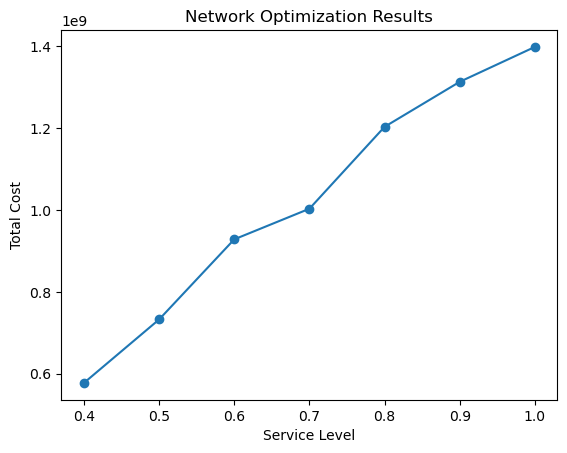

In [ ]:
plt.plot(service_level, [scenario_results[sl]['Total_cost'] for sl in service_level], marker='o')
plt.xlabel('Service Level')
plt.ylabel('Total Cost')
plt.title('Network Optimization Results')
plt.show()

## 6. Exporting output files for BI

In [ ]:
folder = "C:\\Users\\shahz\\OneDrive\\文件\\Shahzeb\\Projects\\Solar Network Optimization\\"
# scenario_results[0.7]['flows_df'].to_csv(f'{folder}flows_0.7.csv', index=False)
# scenario_results[0.7]['facility_status_df'].to_csv(f'{folder}facility_status_0.7.csv', index=False)


In [ ]:
master_flows = []

for sl, result in scenario_results.items():

    temp_df = result['flows_df'].copy()

    temp_df['Service_Level'] = sl
    temp_df['Total_Cost'] = result['Total_cost']
    temp_df['Status'] = result['status']

    master_flows.append(temp_df)

master_flows_df = pd.concat(master_flows, ignore_index=True)
master_flows_df

,Source,Destination,Flow_MW,Transport_Cost,Production_Cost,lane_Cost,Service_Level,Total_Cost,Status
0,Ahmedabad,Ahmedabad,38.0,380000.00,19000000.0,19380000.00,0.4,5.776301e+08,Optimal
1,Ahmedabad,Mumbai,54.0,1485652.28,27000000.0,28485652.28,0.4,5.776301e+08,Optimal
2,Ahmedabad,Pune,32.8,1056961.95,16400000.0,17456961.95,0.4,5.776301e+08,Optimal
3,Ahmedabad,Surat,28.8,364183.75,14400000.0,14764183.75,0.4,5.776301e+08,Optimal
4,Ahmedabad,Indore,14.4,292952.30,7200000.0,7492952.30,0.4,5.776301e+08,Optimal
...,...,...,...,...,...,...,...,...,...
181,Hyderabad,Vijayawada,20.0,308444.44,8600000.0,8908444.44,1.0,1.397494e+09,Infeasible
182,Chennai,Bengaluru,150.0,2727696.00,69000000.0,71727696.00,1.0,1.397494e+09,Infeasible
183,Chennai,Chennai,102.0,1020000.00,46920000.0,47940000.00,1.0,1.397494e+09,Infeasible
184,Chennai,Coimbatore,28.0,748029.49,12880000.0,13628029.49,1.0,1.397494e+09,Infeasible


In [ ]:
cities_df.to_csv(f'{folder}cities_df.csv', index=False)

In [ ]:
flow_map_df = master_flows_df.merge(cities_df.rename(columns={'City': 'Source', 'Latitude': 'Source_Lat', 'Longitude': 'Source_Lon'}), on='Source', how='left') \
    .merge(cities_df.rename(columns={'City': 'Destination', 'Latitude': 'Dest_Lat', 'Longitude': 'Dest_Lon'}), on='Destination', how='left')
flow_map_df.head()

,Source,Destination,Flow_MW,Transport_Cost,Production_Cost,lane_Cost,Service_Level,Total_Cost,Status,Source_Lat,Source_Lon,Dest_Lat,Dest_Lon
0,Ahmedabad,Ahmedabad,38.0,380000.00,19000000.0,19380000.00,0.4,5.776301e+08,Optimal,23.021537,72.580057,23.021537,72.580057
1,Ahmedabad,Mumbai,54.0,1485652.28,27000000.0,28485652.28,0.4,5.776301e+08,Optimal,23.021537,72.580057,19.054999,72.869203
2,Ahmedabad,Pune,32.8,1056961.95,16400000.0,17456961.95,0.4,5.776301e+08,Optimal,23.021537,72.580057,18.521374,73.854507
3,Ahmedabad,Surat,28.8,364183.75,14400000.0,14764183.75,0.4,5.776301e+08,Optimal,23.021537,72.580057,21.209489,72.831706
4,Ahmedabad,Indore,14.4,292952.30,7200000.0,7492952.30,0.4,5.776301e+08,Optimal,23.021537,72.580057,22.720362,75.868200


In [ ]:
flow_map_df.to_csv(f'{folder}flow_map_df.csv', index=False)

In [ ]:
flow_map_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Source           186 non-null    object 
 1   Destination      186 non-null    object 
 2   Flow_MW          186 non-null    float64
 3   Transport_Cost   186 non-null    float64
 4   Production_Cost  186 non-null    float64
 5   lane_Cost        186 non-null    float64
 6   Service_Level    186 non-null    float64
 7   Total_Cost       186 non-null    float64
 8   Status           186 non-null    object 
 9   Source_Lat       186 non-null    float64
 10  Source_Lon       186 non-null    float64
 11  Dest_Lat         186 non-null    float64
 12  Dest_Lon         186 non-null    float64
dtypes: float64(10), object(3)
memory usage: 19.0+ KB


## 7. Key Insights

- Higher service levels significantly increase total network cost, there is a significant increase in the cost after 0.7 service level due to addition of new unit (from 4-> 5)
- Ahmedabad emerged as the most strategically efficient manufacturing hub due to lower production and transportation costs
- Transportation cost contribution remained relatively low compared to production and fixed operating costs
- Some facilities experienced lower utilization under lower service-level scenarios
- The optimization model effectively balanced operational efficiency and customer service requirements

## 8. Conclusion

This project demonstrates how Mixed Integer Linear Programming (MILP) can be applied to real-world supply chain network optimization problems. By combining optimization modeling, geographic analytics, transportation cost engineering, and interactive Power BI visualization, the project provides a scalable framework for strategic supply chain decision-making in the renewable energy sector.

# -------------------------END-THANK YOU----------------------------------